In [64]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [65]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

In [66]:
NUTS2 = 'Thrace'
YEAR = '2025'

In [67]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)

In [68]:
df.head()

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,23.65882,41.33542,0,2025-05-02,EL51,2025,5,2025-05-02,41.333732,23.659379,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-02,41.333732,23.659379,14660.0,NaN,2025-05-02,41.350189,23.650108,2025-05-01,2025-05-01,0.00
1,23.65882,41.33542,0,2025-05-03,EL51,2025,5,2025-05-02,41.333732,23.659379,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-03,41.333732,23.659379,14536.0,14237.0,2025-05-03,41.350189,23.650108,2025-05-02,2025-05-02,0.00
2,23.65882,41.33542,0,2025-05-04,EL51,2025,5,2025-05-02,41.333732,23.659379,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-04,41.333732,23.659379,14362.0,14335.0,2025-05-04,41.350189,23.650108,2025-05-03,2025-05-03,0.00
3,23.65882,41.33542,0,2025-05-05,EL51,2025,5,2025-05-02,41.333732,23.659379,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-05,41.333732,23.659379,14362.0,14335.0,2025-05-05,41.350189,23.650108,2025-05-04,2025-05-04,0.89
4,23.65882,41.33542,0,2025-05-06,EL51,2025,5,2025-05-02,41.333732,23.659379,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-05,41.333732,23.659379,14362.0,14335.0,2025-05-06,41.350189,23.650108,2025-05-05,2025-05-05,2.18


<Axes: >

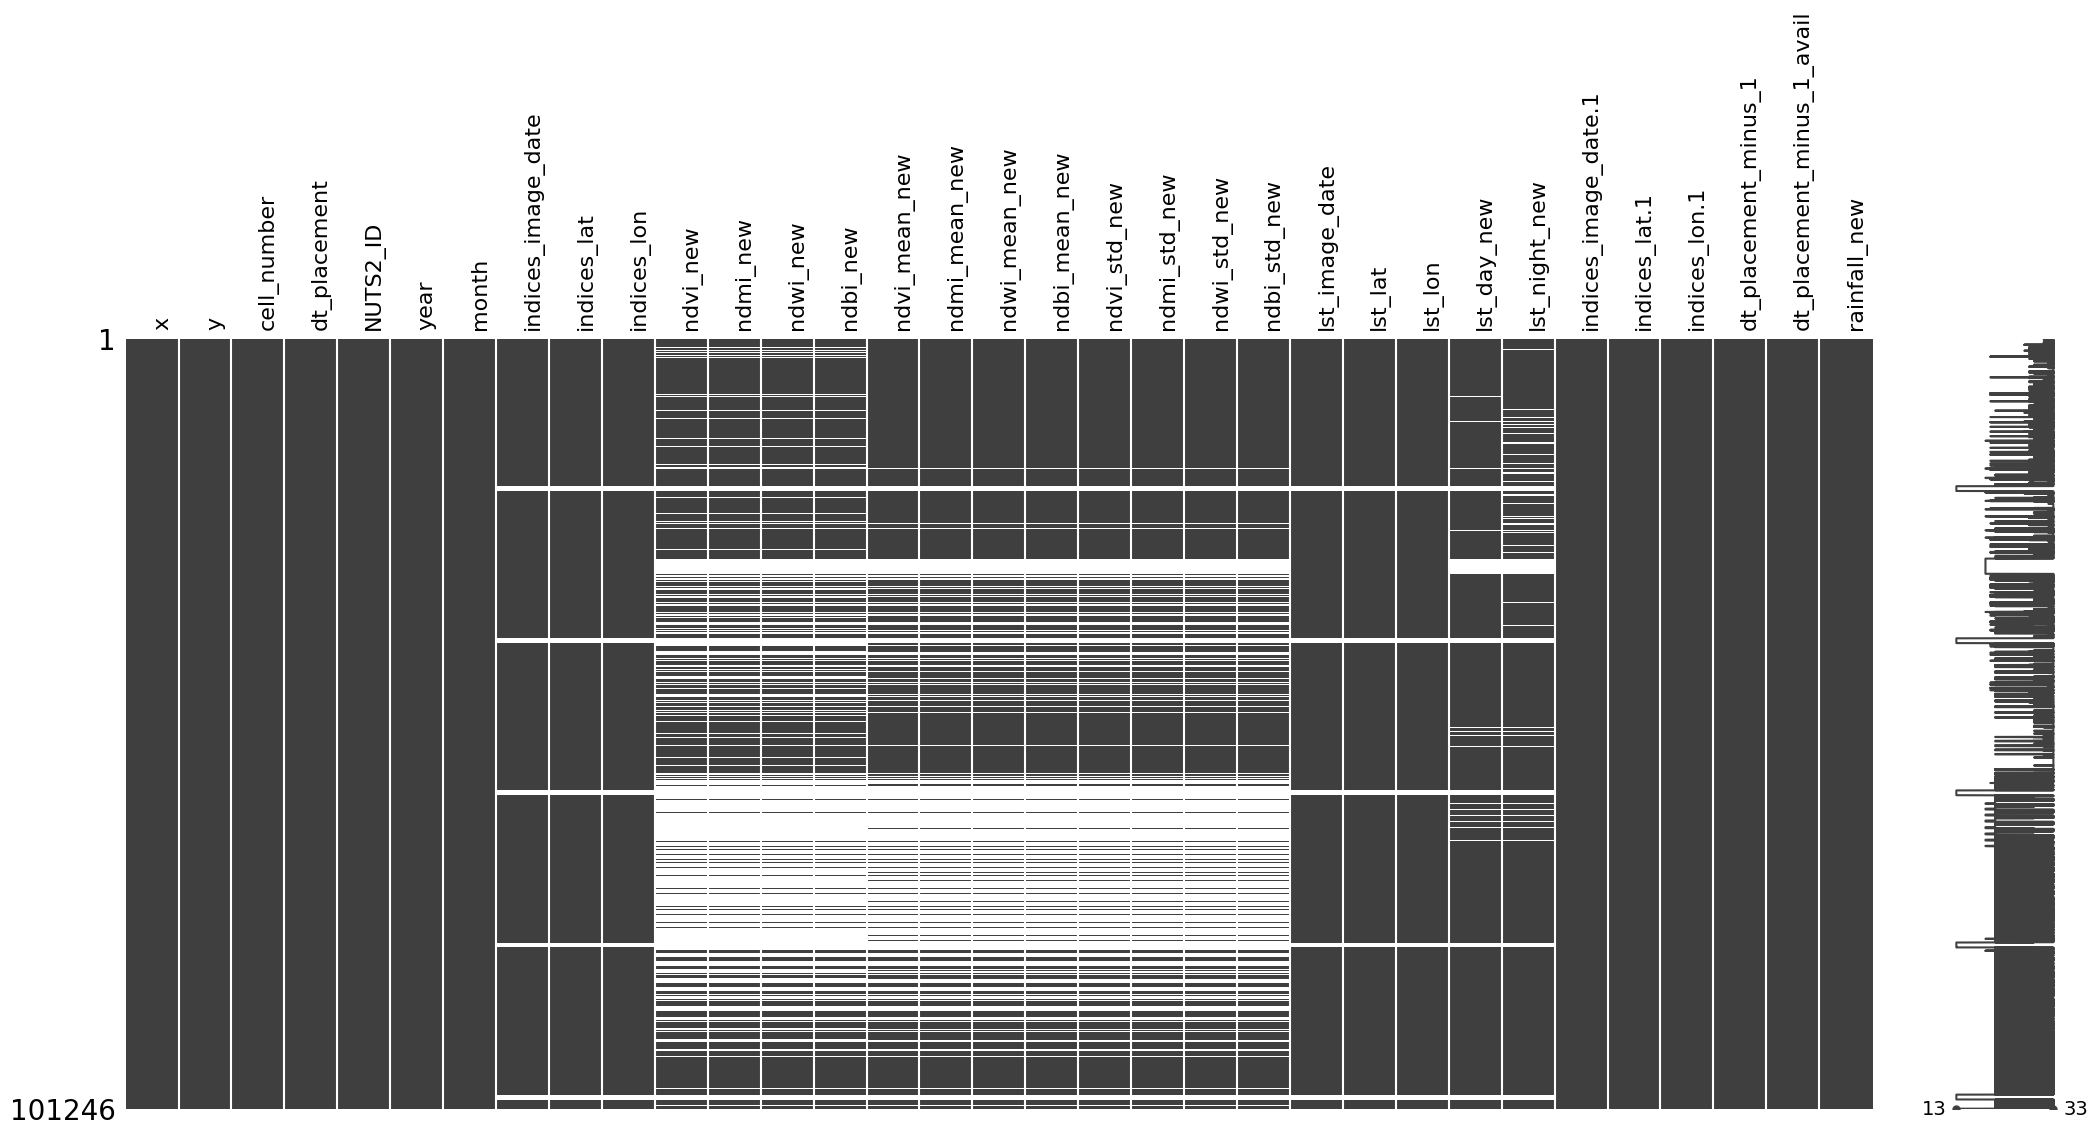

In [69]:
msno.matrix(df, label_rotation=90)

In [70]:
columns_to_drop = ['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1']

for col in columns_to_drop:
    try:
        df.drop(col, axis=1, inplace=True)
    except KeyError:
        print(f"Column {col} not found in DataFrame. Skipping.")

In [71]:
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)

In [72]:
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [73]:
columns_to_convert_to_DT = ['dt_placement', 'indices_image_date', 'lst_image_date', 'rainfall_image_date']

for col in columns_to_convert_to_DT:
    try:
        df[col] = pd.to_datetime(df[col])
    except KeyError:
        print(f"Column {col} not found in DataFrame. Skipping.")

In [74]:
df

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_day,lst_night,rainfall_image_date,rainfall
0,23.65882,41.33542,0,2025-05-02,EL51,2025,5,2025-05-02,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-02,14660.0,NaN,2025-05-01,0.00
1,23.65882,41.33542,0,2025-05-03,EL51,2025,5,2025-05-02,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-03,14536.0,14237.0,2025-05-02,0.00
2,23.65882,41.33542,0,2025-05-04,EL51,2025,5,2025-05-02,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-04,14362.0,14335.0,2025-05-03,0.00
3,23.65882,41.33542,0,2025-05-05,EL51,2025,5,2025-05-02,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-05,14362.0,14335.0,2025-05-04,0.89
4,23.65882,41.33542,0,2025-05-06,EL51,2025,5,2025-05-02,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,2025-05-05,14362.0,14335.0,2025-05-05,2.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101241,26.58397,41.49712,3261,2025-06-01,EL51,2025,6,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2025-05-06,0.00
101242,26.60756,41.35339,3262,2025-06-01,EL51,2025,6,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2025-05-06,0.00
101243,26.60756,41.37135,3263,2025-06-01,EL51,2025,6,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2025-05-06,0.00
101244,26.60756,41.38932,3264,2025-06-01,EL51,2025,6,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2025-05-06,0.00


<Axes: >

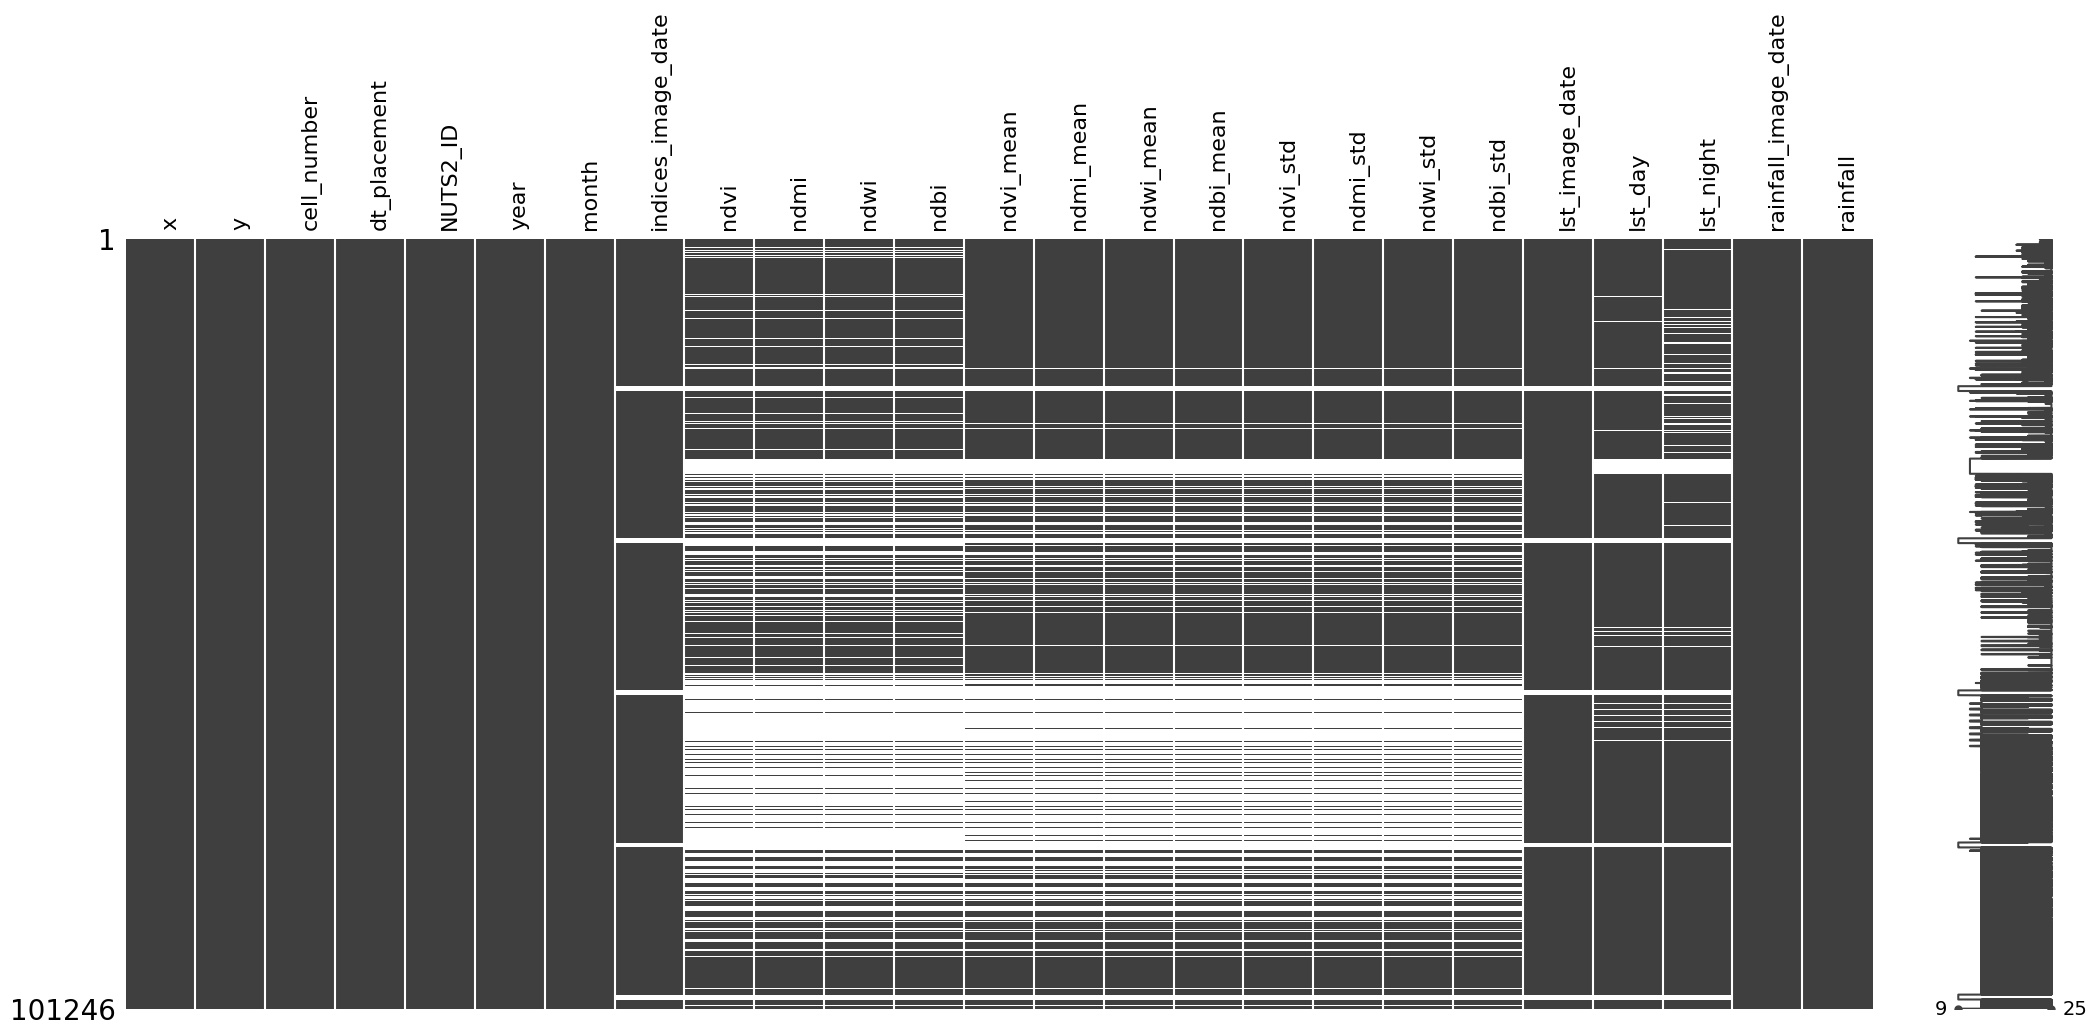

In [75]:
msno.matrix(df, label_rotation=90)

In [76]:
df2 = df.copy()

In [77]:
try:
    indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
except KeyError:
    print("Column 'indices_image_date' not found in DataFrame. Skipping indices mask creation.")
    indices_mask = pd.Series([True] * len(df2))

try:
    lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
except KeyError:
    print("Column 'lst_image_date' not found in DataFrame. Skipping lst mask creation.")
    lst_mask = pd.Series([True] * len(df2))

try:
    rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
except KeyError:
    print("Column 'rainfall_image_date' not found in DataFrame. Skipping rainfall mask creation.")
    rainfall_mask = pd.Series([True] * len(df2))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

<Axes: >

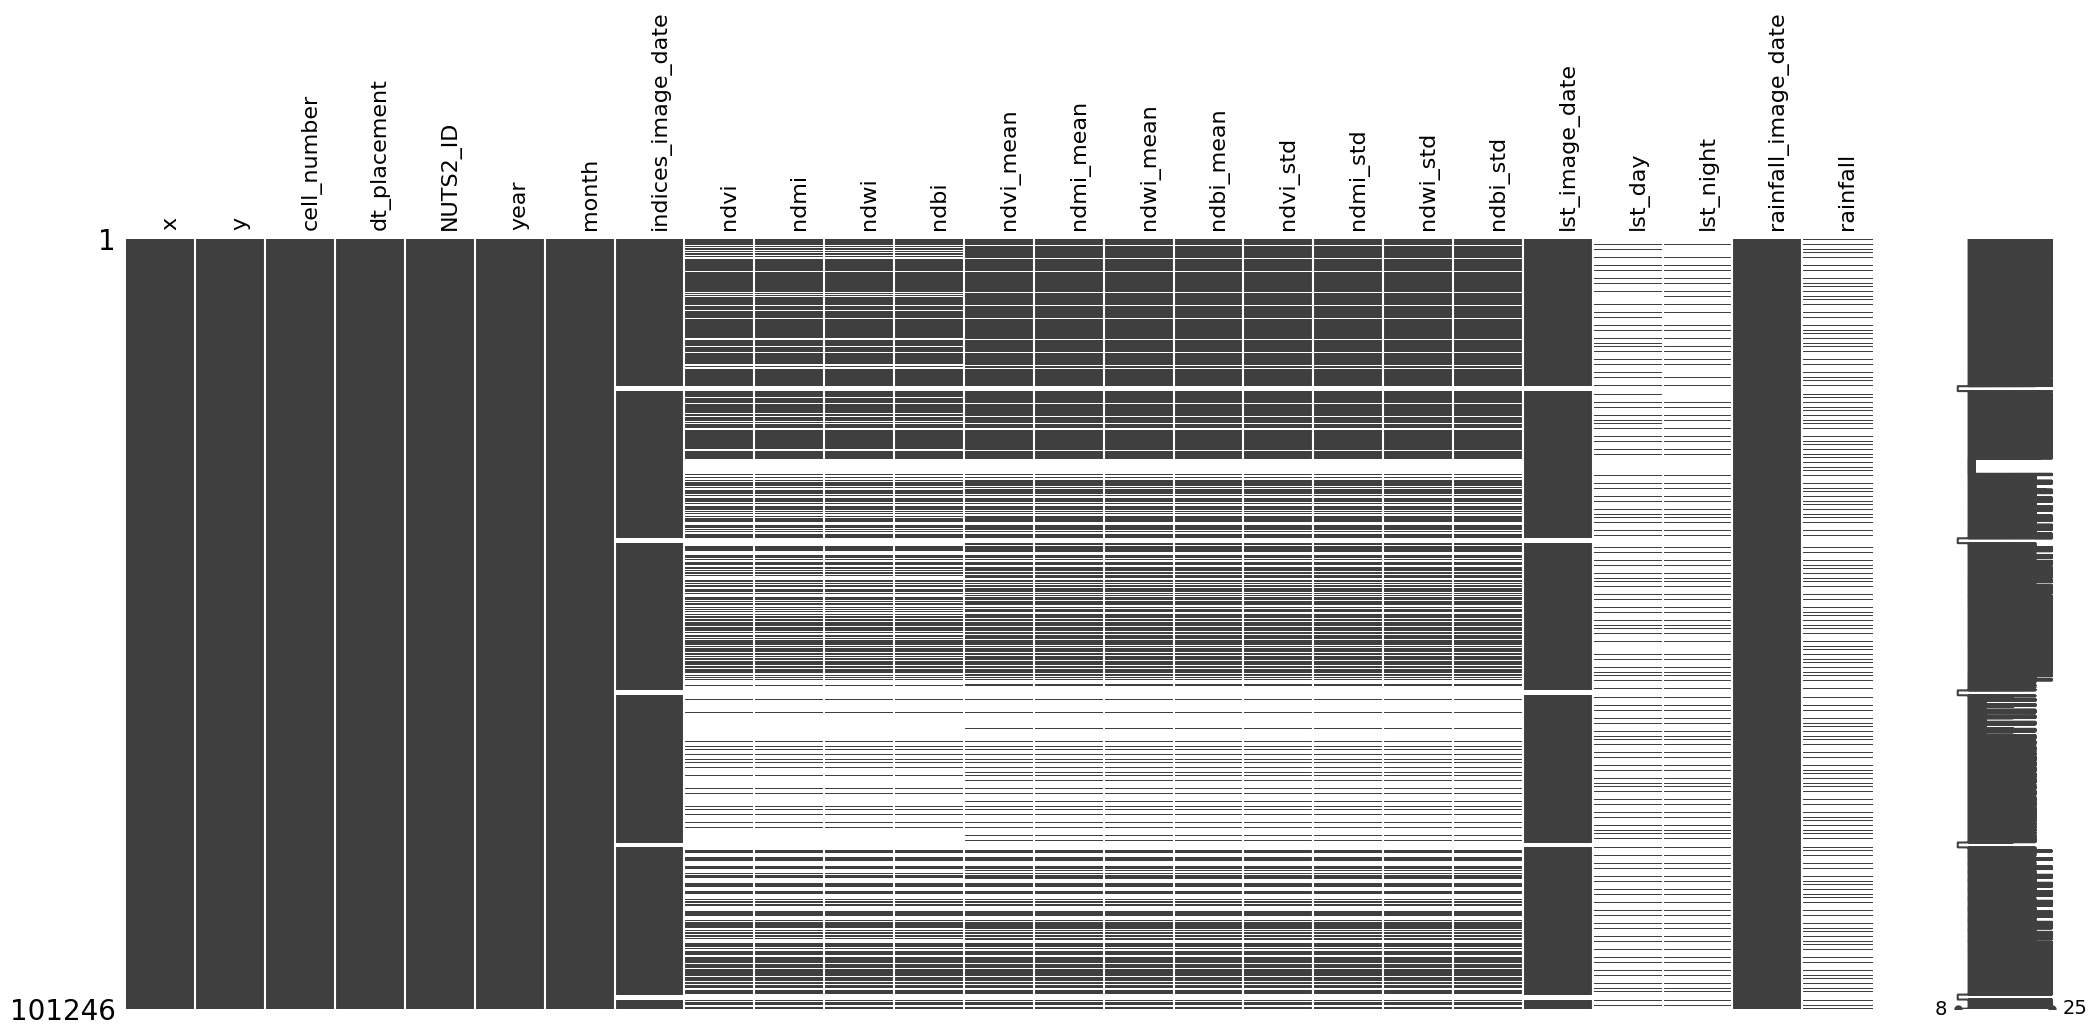

In [78]:
msno.matrix(df2, label_rotation=90)

In [79]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
7,indices_image_date,3.2258
8,ndvi,48.5659
9,ndmi,48.5659
10,ndwi,48.5659
11,ndbi,48.5659
12,ndvi_mean,42.4866
13,ndmi_mean,42.4866
14,ndwi_mean,42.4866
15,ndbi_mean,42.4866
16,ndvi_std,42.4866


In [80]:
columns_to_drop = ['indices_image_date', 'lst_image_date', 'rainfall_image_date']

for col in columns_to_drop:
    try:
        df2.drop(col, axis=1, inplace=True)
    except KeyError:
        print(f"Column {col} not found in DataFrame. Skipping.")

In [81]:
df2.reset_index(drop=True, inplace=True)

In [82]:
df2

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,23.65882,41.33542,0,2025-05-02,EL51,2025,5,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,14660.0,NaN,0.00
1,23.65882,41.33542,0,2025-05-03,EL51,2025,5,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,14536.0,14237.0,0.00
2,23.65882,41.33542,0,2025-05-04,EL51,2025,5,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,14362.0,14335.0,0.00
3,23.65882,41.33542,0,2025-05-05,EL51,2025,5,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,14362.0,14335.0,0.89
4,23.65882,41.33542,0,2025-05-06,EL51,2025,5,0.681529,0.364341,-0.485422,-0.364341,0.561481,0.2898,-0.40373,-0.2898,0.080061,0.058213,0.072986,0.058213,14362.0,14335.0,2.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101241,26.58397,41.49712,3261,2025-06-01,EL51,2025,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101242,26.60756,41.35339,3262,2025-06-01,EL51,2025,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101243,26.60756,41.37135,3263,2025-06-01,EL51,2025,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101244,26.60756,41.38932,3264,2025-06-01,EL51,2025,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

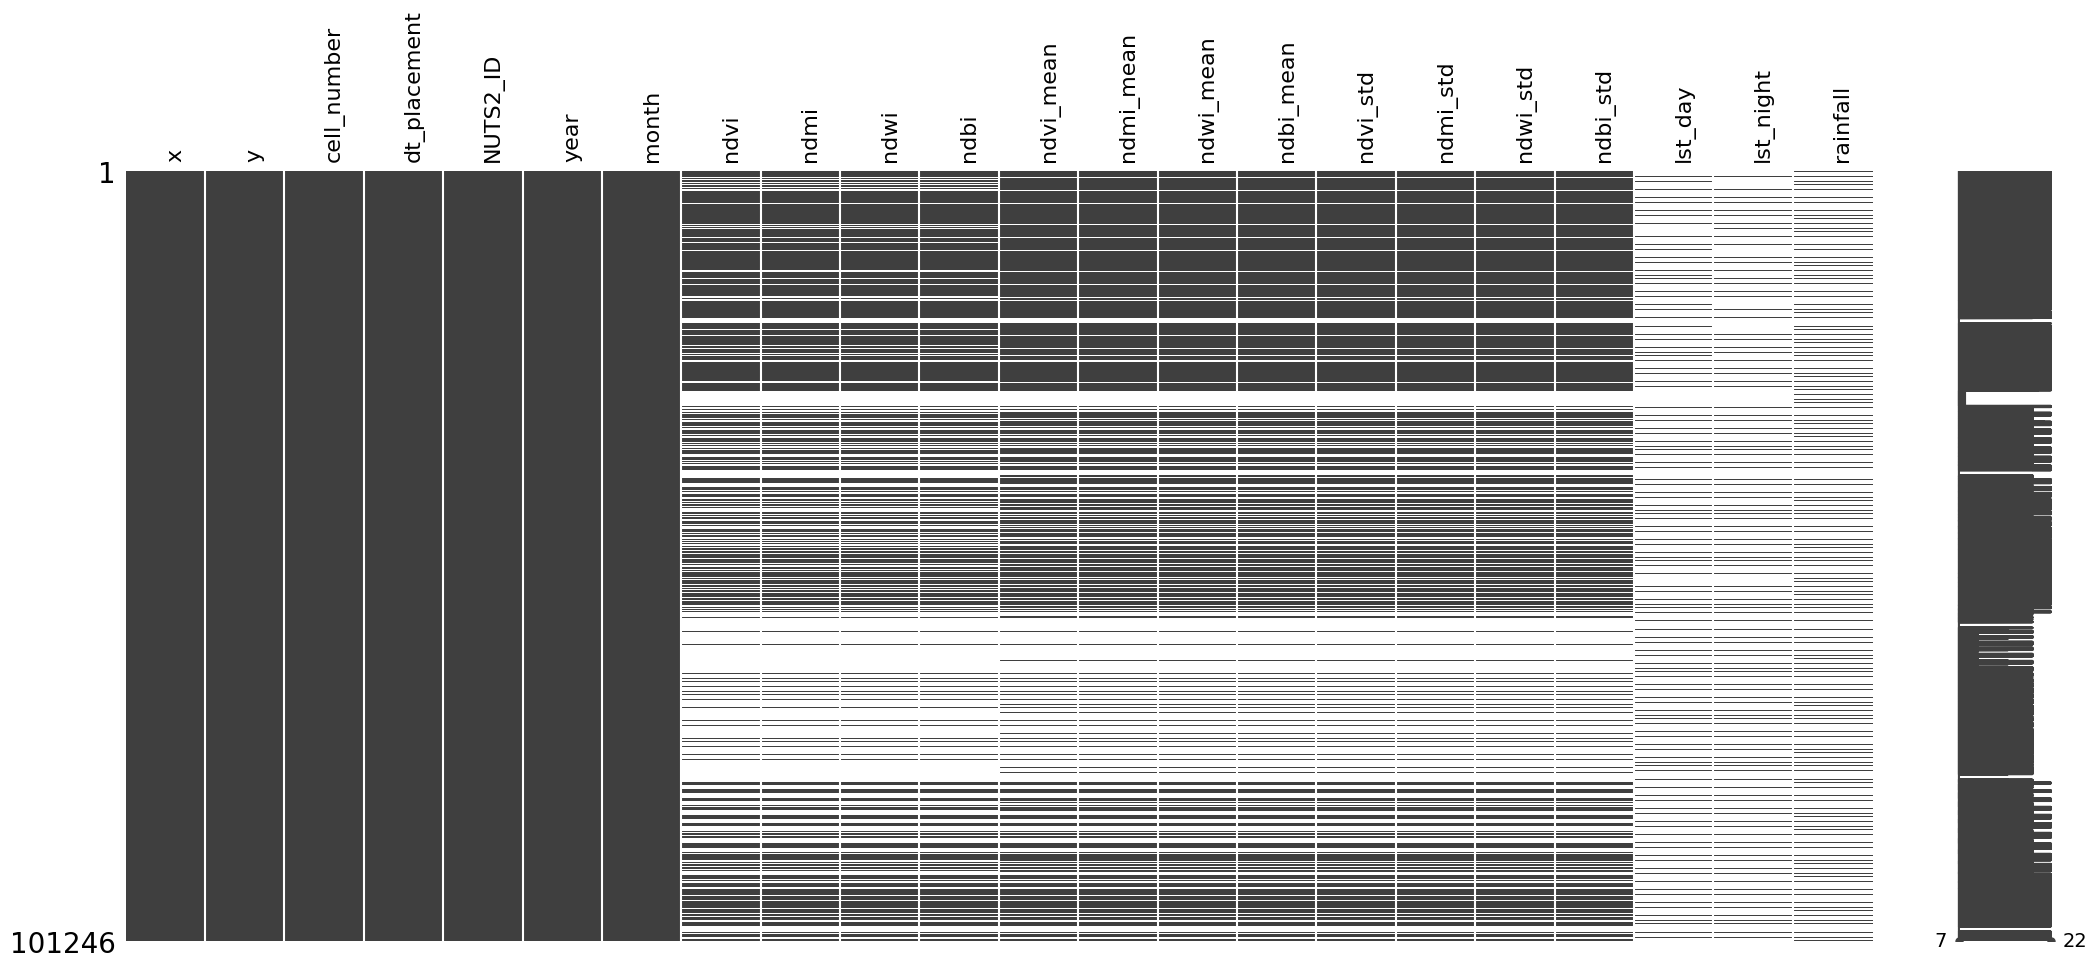

In [83]:
msno.matrix(df2, label_rotation=90)

In [84]:
df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding='utf-8')